# CCO01: Inspect Data and Manifold

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import os
import glob

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO01

In [3]:
# DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/231221/SC149__BVO-14D-JW-121123/filtered_feature_bc_matrix.h5'
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/231221'
OUT_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO01'

## standard scanpy workflow

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO01/umap
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO01/processed
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO01/qc

In [5]:
adata = sc.read_10x_h5(f'{DATA_DIR}/SC149__BVO-14D-JW-121123/filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

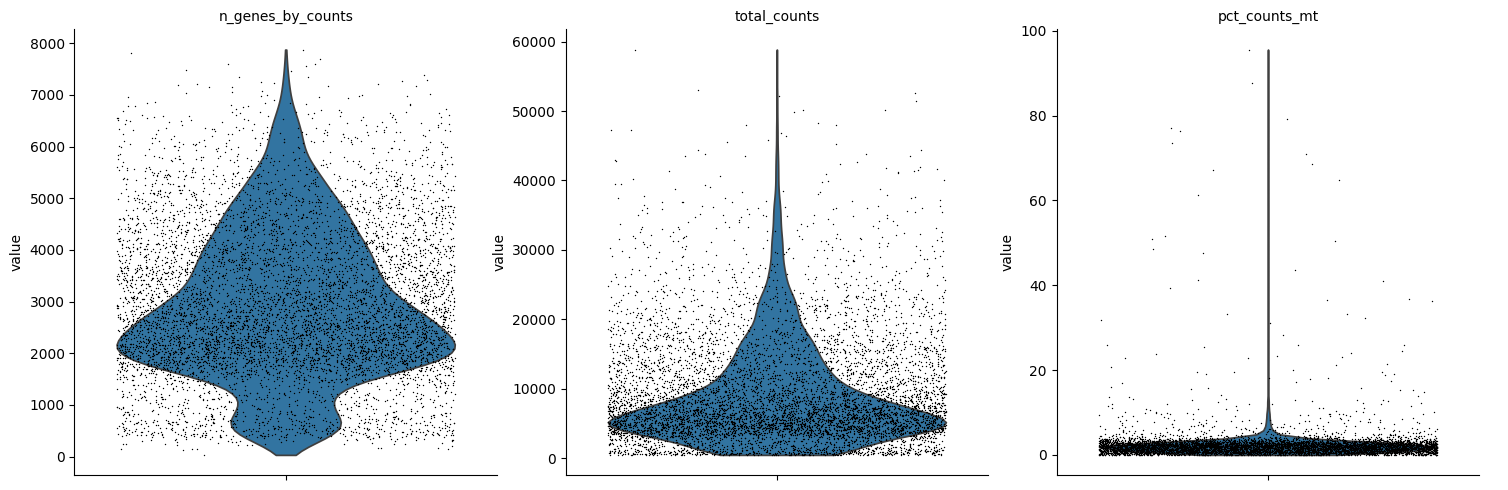

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

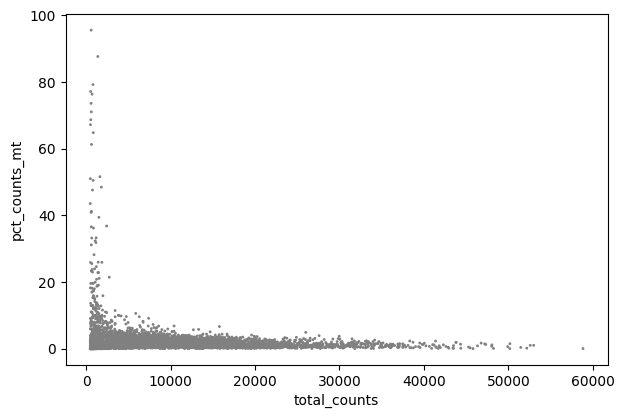

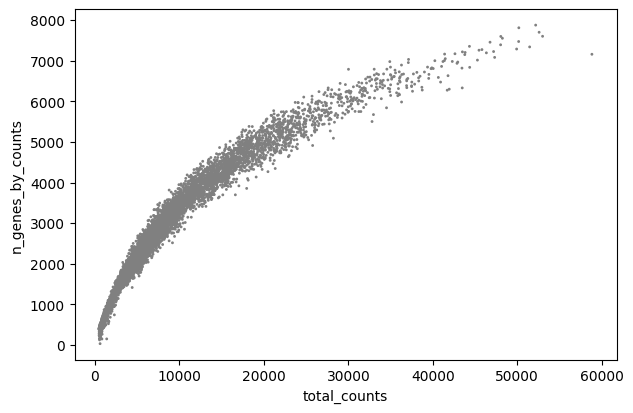

In [8]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=5000)
# adata = adata[:, adata.var['highly_variable']]
sc.pp.scale(adata, max_value=10)

In [10]:
adata

AnnData object with n_obs × n_vars = 7245 × 21707
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'

In [11]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)
sc.tl.umap(adata)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


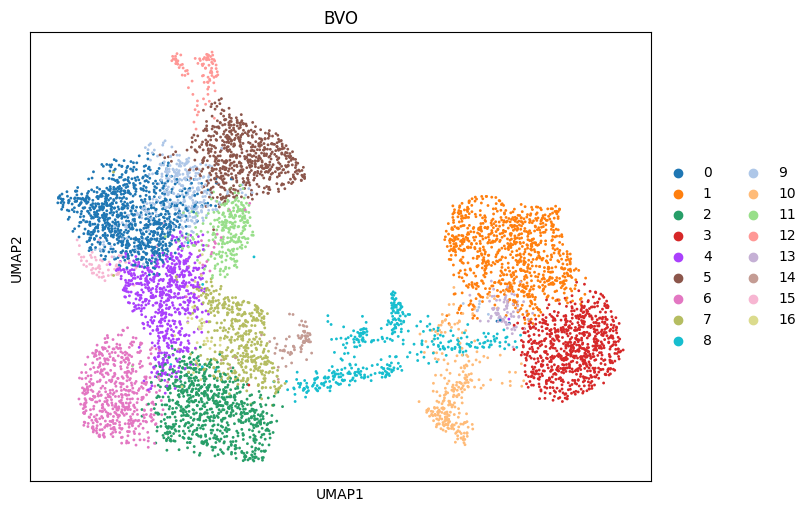

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(8,5), layout="constrained")
# axs = axs.flatten()
sc.pl.umap(adata, color='leiden', ax=axs, title='BVO')
plt.show()

In [20]:
%%capture

for d1 in glob.glob(f"{DATA_DIR}/*"):
    if not os.path.isdir(d1):
        continue
    else:
        sample_name = d1.split('/')[-1]
        
    if not os.path.isdir(f"{OUT_DIR}/qc/{sample_name}"):
        os.mkdir(f"{OUT_DIR}/qc/{sample_name}")
    
    # load h5 file
    adata = sc.read_10x_h5(f'{d1}/filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    
    # QC plots
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sc.pl.violin(
        adata,
        ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
        show=False,
        ax=ax
    )
    plt.savefig(f"{OUT_DIR}/qc/{sample_name}/violin_plots.png")
    plt.close()
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
    sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1])
    plt.savefig(f"{OUT_DIR}/qc/{sample_name}/scatter_plots.png")
    plt.close()
    
    # processing 
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=5000)
    # adata = adata[:, adata.var['highly_variable']]
    sc.pp.scale(adata, max_value=10)
    
    # prepare umap
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.leiden(adata)
    sc.tl.umap(adata)
    
    # write to h5ad
    adata.write(f'{OUT_DIR}/processed/{sample_name}.h5ad')

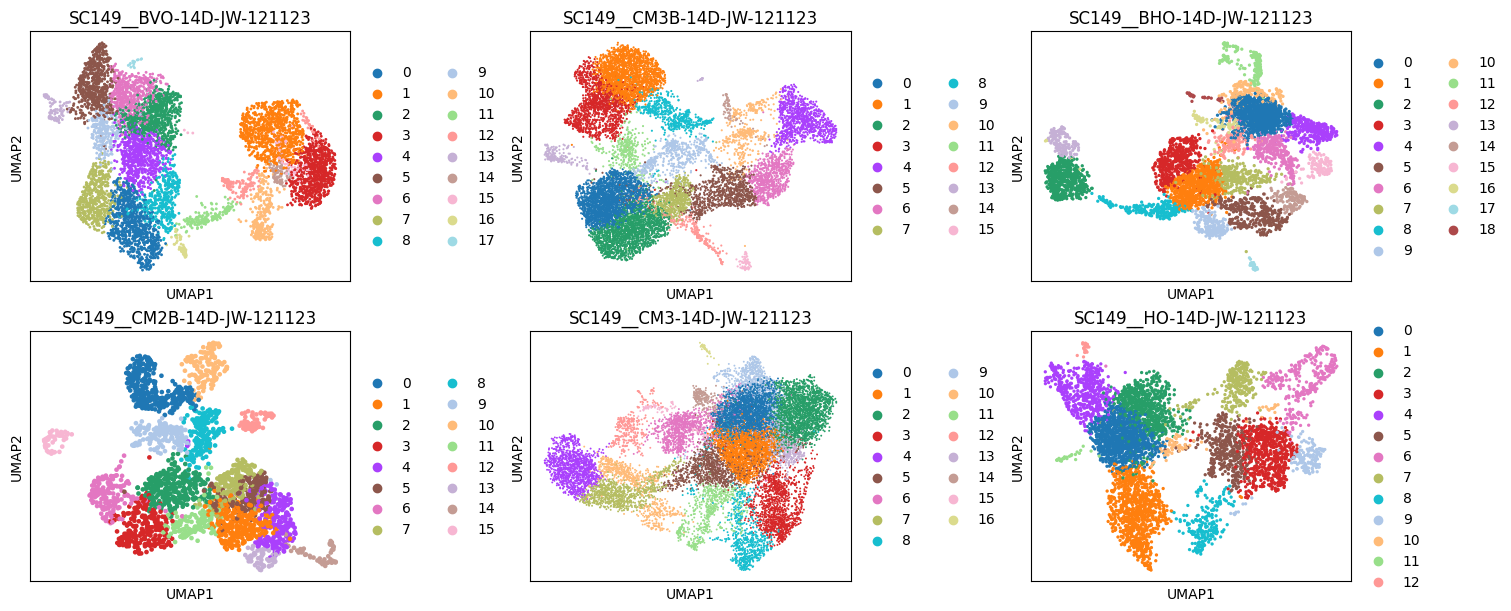

In [21]:
%%capture --no-display
fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/processed/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f'{OUT_DIR}/processed/{sample_name}.h5ad')
    sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False)
    
plt.savefig(f'{OUT_DIR}/umap/umaps.png')
plt.show()

## do co-embedding

In [ ]:
# (adata.var.index == "TNNT2").sum()

## celltype labelling (CellMarker2.0)
 - blood vessel: PECAM1 (CD31)
 - embryonic heart:
   - cardiomyocyte: TNNT2
   - endothelial cell: CDH5?
   - fibroblast and fibroblast-like cell: COL1A1
   - hematopoietic cell: HBB / HBE1
   - smooth muscle cell: ACTG / MYH11 / SM22a
   - valvular cell: SOX9

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(20,12), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/processed/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f'{OUT_DIR}/processed/{sample_name}.h5ad')
    sc.pl.dotplot(adata, var_names=['PECAM1', 'TNNT2', 'SOX9'], groupby='leiden', ax=axs[i], title=sample_name, show=False)
    
plt.show()